In [1]:
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import requests

In [2]:
# Define the API endpoint and parameters
base_url = "https://vannstand.kartverket.no/tideapi.php"
# base_url = "https://api.sehavniva.no/tideapi.php"
params = {
    "lat": 58.9,  # Latitude
    "lon": 5.8,  # Longitude
    "fromtime": "2024-06-05T00:00",  # Start time
    "totime": "2024-06-06T00:00",  # End time
    "datatype": "obs",  # Data type
    "refcode": "cd",  # Reference code
    "place": "AnyHeaderText",  # Place header text
    "file": "",  # File (optional)
    "lang": "nn",  # Language
    "interval": 10,  # Interval in minutes
    "dst": 0,  # Daylight saving time
    "tzone": 1,  # Time zone
    "tide_request": "locationdata",  # Tide request type
}
# Make the API request
response = requests.get(base_url, params=params)

In [3]:
response.__dict__  # Print reponse contents

{'_content': b'<tide>\n<locationdata>\n<location name="Stavanger" code="SVG" latitude="58.900000" longitude="5.800000" delay="0" factor="1.00" obsname="Stavanger" obscode="SVG" place="AnyHeaderText" descr="Tidvatn og observert vasstand fr\xc3\xa5 Stavanger"/>\n<reflevelcode>CD</reflevelcode>\n<data type="observation" unit="cm" qualityFlag="0" qualityClass="Quality Not Set" qualityDescription="Kvalitet er ikkje klassifisert: Her manglar vi enten m\xc3\xa5lingar vi kan bruke til \xc3\xa5 vurdere kvaliteten med, eller s\xc3\xa5 er vurdering av kvalitet enno ikkje utf\xc3\xb8rt.">\n<waterlevel value="72.4" time="2024-06-05T00:00:00+01:00" flag="obs"/>\n<waterlevel value="71.4" time="2024-06-05T00:10:00+01:00" flag="obs"/>\n<waterlevel value="70.3" time="2024-06-05T00:20:00+01:00" flag="obs"/>\n<waterlevel value="69.1" time="2024-06-05T00:30:00+01:00" flag="obs"/>\n<waterlevel value="67.5" time="2024-06-05T00:40:00+01:00" flag="obs"/>\n<waterlevel value="65.5" time="2024-06-05T00:50:00+01:0

In [4]:
print(response.status_code)  # Print the status code
print(response.text)  # Print the response text

200
<tide>
<locationdata>
<location name="Stavanger" code="SVG" latitude="58.900000" longitude="5.800000" delay="0" factor="1.00" obsname="Stavanger" obscode="SVG" place="AnyHeaderText" descr="Tidvatn og observert vasstand frå Stavanger"/>
<reflevelcode>CD</reflevelcode>
<data type="observation" unit="cm" qualityFlag="0" qualityClass="Quality Not Set" qualityDescription="Kvalitet er ikkje klassifisert: Her manglar vi enten målingar vi kan bruke til å vurdere kvaliteten med, eller så er vurdering av kvalitet enno ikkje utført.">
<waterlevel value="72.4" time="2024-06-05T00:00:00+01:00" flag="obs"/>
<waterlevel value="71.4" time="2024-06-05T00:10:00+01:00" flag="obs"/>
<waterlevel value="70.3" time="2024-06-05T00:20:00+01:00" flag="obs"/>
<waterlevel value="69.1" time="2024-06-05T00:30:00+01:00" flag="obs"/>
<waterlevel value="67.5" time="2024-06-05T00:40:00+01:00" flag="obs"/>
<waterlevel value="65.5" time="2024-06-05T00:50:00+01:00" flag="obs"/>
<waterlevel value="63.1" time="2024-06-0

In [5]:
xml_root = ET.fromstring(response.text)

In [6]:
xml_root

<Element 'tide' at 0x00000298A8E681D0>

In [7]:
waterlevels = xml_root.findall(".//data/waterlevel")

In [8]:
time = []
water_level = []

for waterlevel in waterlevels:
    timestamp = waterlevel.attrib.get("time")  # Get the 'time' attribute
    value = waterlevel.attrib.get("value")  # Get the 'value' attribute
    if timestamp and value:
        time.append(timestamp)
        water_level.append(float(value))
    # print(f"Timestamp: {timestamp}, Water Level: {value}")

time = np.array(time, dtype="datetime64[s]")

C:\Users\mha114\AppData\Local\Temp\ipykernel_44932\786370774.py:12: UserWarning: no explicit representation of timezones available for np.datetime64
  time = np.array(time, dtype="datetime64[s]")


In [9]:
print(time)

['2024-06-04T23:00:00' '2024-06-04T23:10:00' '2024-06-04T23:20:00'
 '2024-06-04T23:30:00' '2024-06-04T23:40:00' '2024-06-04T23:50:00'
 '2024-06-05T00:00:00' '2024-06-05T00:10:00' '2024-06-05T00:20:00'
 '2024-06-05T00:30:00' '2024-06-05T00:40:00' '2024-06-05T00:50:00'
 '2024-06-05T01:00:00' '2024-06-05T01:10:00' '2024-06-05T01:20:00'
 '2024-06-05T01:30:00' '2024-06-05T01:40:00' '2024-06-05T01:50:00'
 '2024-06-05T02:00:00' '2024-06-05T02:10:00' '2024-06-05T02:20:00'
 '2024-06-05T02:30:00' '2024-06-05T02:40:00' '2024-06-05T02:50:00'
 '2024-06-05T03:00:00' '2024-06-05T03:10:00' '2024-06-05T03:20:00'
 '2024-06-05T03:30:00' '2024-06-05T03:40:00' '2024-06-05T03:50:00'
 '2024-06-05T04:00:00' '2024-06-05T04:10:00' '2024-06-05T04:20:00'
 '2024-06-05T04:30:00' '2024-06-05T04:40:00' '2024-06-05T04:50:00'
 '2024-06-05T05:00:00' '2024-06-05T05:10:00' '2024-06-05T05:20:00'
 '2024-06-05T05:30:00' '2024-06-05T05:40:00' '2024-06-05T05:50:00'
 '2024-06-05T06:00:00' '2024-06-05T06:10:00' '2024-06-05T06:20

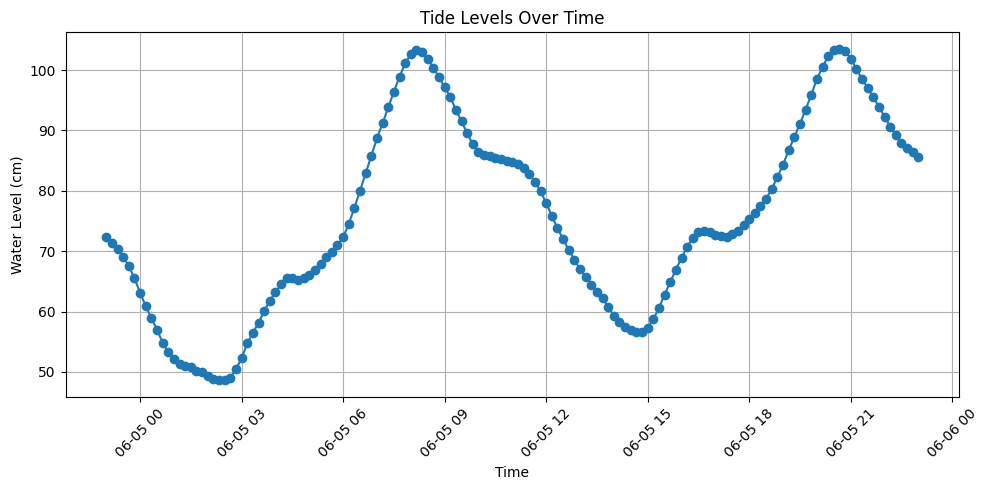

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(time, water_level, marker="o")
plt.title("Tide Levels Over Time")
plt.xlabel("Time")
plt.ylabel("Water Level (cm)")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [12]:
# Define the API endpoint and parameters
base_url = "https://vannstand.kartverket.no/tideapi.php"
# base_url = "https://api.sehavniva.no/tideapi.php"
params = {
    "lat": 68.69,  # Latitude
    "lon": 15.43,  # Longitude
    "fromtime": "2024-06-05T00:00",  # Start time
    "totime": "2024-06-06T00:00",  # End time
    "datatype": "tab",  # Data type
    "refcode": "cd",  # Reference code
    "place": "AnyHeaderText",  # Place header text
    "file": "",  # File (optional)
    "lang": "nn",  # Language
    "interval": 10,  # Interval in minutes
    "dst": 0,  # Daylight saving time
    "tzone": 1,  # Time zone
    "tide_request": "locationdata",  # Tide request type
}
# Make the API request
response = requests.get(base_url, params=params)
print(response.text)

<tide>
<locationdata>
<location name="Andenes" code="ANX" latitude="68.690000" longitude="15.430000" delay="-5" factor="1.00" obsname="Andenes" obscode="ANX" place="AnyHeaderText" descr="Tidvatn justert med −5 minutt og høgdefaktor 1,00 frå Andenes"/>
<reflevelcode>CD</reflevelcode>
<data type="prediction" unit="cm" qualityFlag="2" qualityClass="Quality OK" qualityDescription="Data av god kvalitet egna til dei fleste formål: Det er verifisert mot målingar at data stemmer ganske godt med fysiske forhold, eller det er data vi antar stemmer godt med fysiske forhold, uten at det er verifisert mot målingar.">
<waterlevel value="41.1" time="2024-06-05T05:27:00+01:00" flag="low"/>
<waterlevel value="203.0" time="2024-06-05T11:32:00+01:00" flag="high"/>
<waterlevel value="29.7" time="2024-06-05T17:49:00+01:00" flag="low"/>
</data>
</locationdata>
</tide>



In [13]:
location = xml_root.findall(".//locationdata/location")

In [14]:
for l in location:
    print(l.attrib)

{'name': 'Stavanger', 'code': 'SVG', 'latitude': '58.900000', 'longitude': '5.800000', 'delay': '0', 'factor': '1.00', 'obsname': 'Stavanger', 'obscode': 'SVG', 'place': 'AnyHeaderText', 'descr': 'Tidvatn og observert vasstand frå Stavanger'}
